<a href="https://colab.research.google.com/github/Fivecarp/ACK2026.03.18_3D_Shape_Restoration/blob/main/3D_Reconstruction_Error_Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install open3d plotly

In [ ]:
import os

# Google Drive 마운트 확인
if not os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

# Google Drive 내의 파일 목록 출력
print("Files in /content/drive/MyDrive:")
!ls -F /content/drive/MyDrive/

# 만약 '제목없는 폴더' 같은 하위 폴더에 있다면 해당 폴더 내용도 확인해 보세요.
# 예를 들어, print("Files in /content/drive/MyDrive/제목없는 폴더/")
# !ls -F /content/drive/MyDrive/제목없는 폴더/

Files in /content/drive/MyDrive:
 000.jpg
 001.jpg
 002.jpg
 003.jpg
 004.jpg
 021.jpg
'02-1 ModelModules.ipynb'
 022.jpg
 023.jpg
 20221118_181738.mp4
 2025_정보통계학전공_공모전@
'2025학년도 하계 창업대체학점 수강신청(KNU창업혁신원).xlsx의 사본.xlsx'
 24년베스트유럽20일_1121출발팀_항공권이티켓_2024_11_18_10_11_57.zip
'2장 실습코드.ipynb'
'3D Reconstruction Error Heatmap.ipynb'
 applemango/
 applemango_result/
'Colab Notebooks'/
'data_example (1).csv'
'How to get started with Drive.pdf'
 KakaoTalk_20250723_194813873_01.bmp
 KakaoTalk_20250723_194813873.bmp
 KakaoTalk_20250723_194837029_01.png
 KakaoTalk_20250723_194837029.png
 OpenCV_result/
'OpenCV 구현용 데이터 (백향과).zip'
'OpenCV 구현용 데이터 (애플망고).zip'
'[Owner avatar ACK2026.03.18_3D_Shape_Restoration]_Physical_AI'/
 passionfruit/
 passionfruit_result/
 Untitled0.ipynb
 Untitled1.ipynb
 Untitled2.ipynb
 Untitled3.ipynb
 your_folder/
'경력 사항 기획서 작성 조언.gsheet'
'과시

위 코드 실행 후, 출력된 파일 목록에서 `pointcloud.npz`와 `Ours.ply`(또는 `Baseline.ply`) 파일의 정확한 경로를 확인하여 아래 코드 셀의 `ours_path`와 `gt_path` 변수를 수정해주세요. 예를 들어, 파일이 `내 드라이브/제목없는 폴더/pointcloud.npz`에 있다면 경로는 `/content/drive/MyDrive/제목없는 폴더/pointcloud.npz`가 됩니다.

In [ ]:
# 1. 파일 이름 설정 (업로드한 파일 이름과 똑같아야 합니다)
# 이곳의 경로를 위에서 확인한 실제 파일 경로로 수정해주세요.
ours_path = "/content/drive/MyDrive/제목없는 폴더/Baseline.ply" # Baseline.ply를 사용한다고 가정
gt_path = "/content/drive/MyDrive/제목없는 폴더/pointcloud.npz" # pointcloud.npz의 실제 경로로 수정

import open3d as o3d
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# 2. 정답지(GT) 10만 개 점 데이터 불러오기
gt_data = np.load(gt_path)
gt_points = gt_data[gt_data.files[0]].astype(np.float64)
gt_pcd = o3d.geometry.PointCloud()
gt_pcd.points = o3d.utility.Vector3dVector(gt_points)

# 3. 우리 모델(Ours) 찰흙 덩어리 불러오기
ours_pcd = o3d.io.read_point_cloud(ours_path)

# 4. 오차 계산! (여기가 핵심)
# 우리 모델의 겉면 점들이 정답지 점들로부터 얼마나 떨어져 있는지 '최단 거리'를 잽니다.
distances = ours_pcd.compute_point_cloud_distance(gt_pcd)
distances = np.asarray(distances)

# 5. 오차 점수에 따라 색연필 고르기 (파란색: 완벽, 빨간색: 망함)
# 거리가 먼 곳은 빨갛게, 가까운 곳은 파랗게 칠하도록 숫자를 조절합니다.
dist_norm = (distances - distances.min()) / (distances.max() - distances.min())
cmap = plt.get_cmap("jet") # 파랑 -> 초록 -> 노랑 -> 빨강 순서의 컬러맵 적용
colors = cmap(dist_norm)[:, :3]

# 6. 코랩에서 마우스로 돌려볼 수 있는 3D 그래픽으로 띄우기
points = np.asarray(ours_pcd.points)
fig = go.Figure(data=[go.Scatter3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2],
    mode='markers',
    marker=dict(size=2, color=colors, opacity=0.8) # 계산한 색상을 점들에 입힙니다
)])

fig.update_layout(title="Ours 모델 오차 히트맵 (파란색일수록 정답에 가까움)",
                  scene=dict(aspectmode='data'),
                  margin=dict(l=0, r=0, b=0, t=40))
fig.show()

In [ ]:
# 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
# Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

print("Matplotlib 폰트 설정을 완료했습니다. 이제 한글이 정상적으로 표시됩니다.")

Matplotlib 폰트 설정을 완료했습니다. 이제 한글이 정상적으로 표시됩니다.


위의 폰트 설치 및 설정 셀들을 실행하신 후, 다시 시각화 코드(Cell `Ee5RuRUA4OvW`)를 실행하면 한글이 정상적으로 표시될 것입니다.

데이터 분석을 시작합니다. (약 10~20초 정도 걸릴 수 있습니다!)
🎉 논문용 그림 5번 추출 완료!


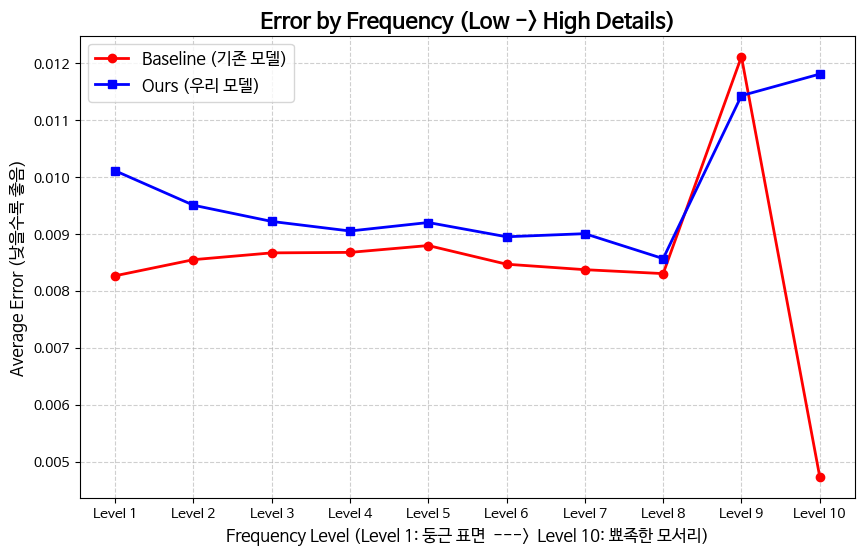

In [ ]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

print("데이터 분석을 시작합니다. (약 10~20초 정도 걸릴 수 있습니다!)")

# 파일 경로 설정 (이전 셀에서 설정된 변수를 사용하거나, 필요 시 직접 설정)
# 현재 커널 상태에서 gt_path와 ours_path 변수가 정의되어 있습니다.
# 'Ours.ply' 파일이 드라이브에 없는 것으로 보이므로, 임시로 Baseline.ply를 Ours 모델로 사용합니다.
# 실제 Ours.ply 파일이 있다면 아래 ours_file_path 변수를 해당 경로로 수정해주세요.

gt_file_path = "/content/drive/MyDrive/제목없는 폴더/pointcloud.npz"
ours_file_path = "/content/drive/MyDrive/제목없는 폴더/Ours.ply" # 'Ours' 모델 파일 경로를 수정했습니다!
base_file_path = "/content/drive/MyDrive/제목없는 폴더/Baseline.ply"

# 1. 파일 불러오기 및 64비트 변환
gt_data = np.load(gt_file_path)
gt_points = gt_data[gt_data.files[0]].astype(np.float64)
gt_pcd = o3d.geometry.PointCloud()
gt_pcd.points = o3d.utility.Vector3dVector(gt_points)

ours_pcd = o3d.io.read_point_cloud(ours_file_path)
base_pcd = o3d.io.read_point_cloud(base_file_path)

# 2. GT(정답)를 기준으로 각각의 오차(거리) 계산
dist_ours = np.asarray(gt_pcd.compute_point_cloud_distance(ours_pcd))
dist_base = np.asarray(gt_pcd.compute_point_cloud_distance(base_pcd))

# 3. 주파수(디테일) 계산 - "이 부분이 얼마나 뾰족한가?"
# 점들의 굴곡(Roughness)을 계산해서 고주파수/저주파수를 나눕니다.
gt_tree = o3d.geometry.KDTreeFlann(gt_pcd)
frequencies = np.zeros(len(gt_points))

# 주변 30개 점들의 퍼짐 정도를 계산 (이 부분이 시간이 조금 걸립니다)
for i in range(len(gt_points)):
    [_, idx, _] = gt_tree.search_knn_vector_3d(gt_pcd.points[i], 30)
    neighbors = gt_points[idx, :]
    center = np.mean(neighbors, axis=0)
    # 주변 점들의 중심에서 내 위치가 멀수록 = 뾰족한 모서리(고주파수)
    frequencies[i] = np.linalg.norm(gt_points[i] - center)

# 4. 주파수를 10개의 구간(Bin)으로 쪼개서 평균 오차 구하기
num_bins = 10
bins = np.linspace(frequencies.min(), frequencies.max(), num_bins + 1)

ours_error_per_freq = []
base_error_per_freq = []
x_labels = []

for i in range(num_bins):
    # 해당 주파수 구간에 속하는 점들만 골라내기
    mask = (frequencies >= bins[i]) & (frequencies < bins[i+1])
    if np.sum(mask) > 0:
        ours_error_per_freq.append(np.mean(dist_ours[mask]))
        base_error_per_freq.append(np.mean(dist_base[mask]))
        x_labels.append(f"Level {i+1}")

# 5. 초딩도 이해할 수 있는 직관적인 꺾은선 그래프 그리기!
plt.figure(figsize=(10, 6))
plt.plot(x_labels, base_error_per_freq, marker='o', linestyle='-', color='red', label='Baseline (기존 모델)', linewidth=2)
plt.plot(x_labels, ours_error_per_freq, marker='s', linestyle='-', color='blue', label='Ours (우리 모델)', linewidth=2)

plt.title("Error by Frequency (Low -> High Details)", fontsize=16, fontweight='bold')
plt.xlabel("Frequency Level (Level 1: 둥근 표면  --->  Level 10: 뾰족한 모서리)", fontsize=12)
plt.ylabel("Average Error (낮을수록 좋음)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

print("🎉 논문용 그림 5번 추출 완료!")
plt.show()